# Day 2 — Tiny Real/Fake Classifier (PyTorch practice)

**Owner:** Person 3 (ML lead) · Phase 0.5, Day 2

This notebook is a *practice harness*, not a real detector. Its only job is to
exercise the full PyTorch training loop end-to-end on the Day 1 face crops, so the
whole team can read and reuse the pattern:

1. `Dataset` / `DataLoader`
2. a small model with a classification **head**
3. a **training** loop
4. a **validation** loop

**About the labels (read this).** Every crop we have is a *real* face. To get a
real/fake task we synthesize it: each real crop is paired with a **degraded copy**
(blur / JPEG artifacts / colour shift) labelled `fake`. So the model actually learns
*"clean vs tampered,"* an honest stand-in for the real job. Genuine deepfake data
(FakeAVCeleb) replaces this later.

**Scope, kept deliberately small:**
- Model is a tiny from-scratch CNN. **Pretrained backbones / freeze-unfreeze are Day 4.**

**Running this yourself:** open in Jupyter or VS Code and *Restart Kernel & Run All* —
every cell runs top to bottom with no manual steps or hidden state. Requires the
repo's `.venv` (see [README.md](../README.md)) and Day 1's face crops already present
under `preprocessing/output_crops/`.

In [1]:
import io
import random
from pathlib import Path

import numpy as np
from PIL import Image, ImageFilter, ImageEnhance
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Reproducibility: fix every RNG so runs are comparable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Day 1 confirmed CUDA works (RTX 5070 Ti). Fall back to CPU anywhere else.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


## 1. Find the practice crops

`crop_faces.py` (Day 1) wrote 224x224 face crops under `preprocessing/output_crops/`.
We locate that folder whether the notebook is launched from the repo root
(interactive Jupyter) or from `notebooks/` (headless execution).

In [2]:
def find_crops_dir():
    """Walk upward from the working directory to find preprocessing/output_crops."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "preprocessing" / "output_crops"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find preprocessing/output_crops. "
        "Run preprocessing/crop_faces.py first (see README)."
    )

CROPS_DIR = find_crops_dir()
real_paths = sorted(CROPS_DIR.rglob("*.jpg"))
assert real_paths, f"No .jpg crops found under {CROPS_DIR}"
print(f"Found {len(real_paths)} real face crops in {CROPS_DIR}")

Found 883 real face crops in C:\Users\vaibh\Documents\GitHub\deepfake-detection\preprocessing\output_crops


## 2. Split by source image *before* making fakes (avoid leakage)

Each real crop will spawn one `real` and one `fake` sample. If the same face landed
in both train and val, the model could recognise the *face* instead of learning
clean-vs-tampered. So we split the **list of source images** first, then expand each
side into real + fake.

In [3]:
VAL_FRACTION = 0.2

shuffled = real_paths.copy()
random.Random(SEED).shuffle(shuffled)          # deterministic shuffle
n_val = int(len(shuffled) * VAL_FRACTION)
val_images = shuffled[:n_val]
train_images = shuffled[n_val:]
print(f"{len(train_images)} train images, {len(val_images)} val images "
      f"(before real/fake expansion)")

707 train images, 176 val images (before real/fake expansion)


## 3. What makes a "fake"

A fake is a real crop passed through one randomly-chosen degradation. The choice is
seeded per-sample, so a given fake is identical every epoch — important, because the
validation set must not wobble from epoch to epoch.

In [4]:
def corrupt(img: Image.Image, seed: int) -> Image.Image:
    """Return a degraded copy of a face crop — our stand-in for a 'fake'.

    One of three degradations, chosen deterministically from `seed`:
      - Gaussian blur      (softens fine detail)
      - JPEG recompression (adds block artifacts)
      - colour/brightness shift
    """
    rng = random.Random(seed)
    kind = rng.choice(["blur", "jpeg", "color"])

    if kind == "blur":
        return img.filter(ImageFilter.GaussianBlur(radius=rng.uniform(2.5, 4.5)))

    if kind == "jpeg":
        buffer = io.BytesIO()
        img.save(buffer, format="JPEG", quality=rng.randint(5, 12))
        buffer.seek(0)
        return Image.open(buffer).convert("RGB")   # convert() forces a full load

    # color: push saturation and brightness clearly away from the original
    img = ImageEnhance.Color(img).enhance(rng.uniform(0.15, 0.45))
    img = ImageEnhance.Brightness(img).enhance(rng.uniform(0.55, 0.8))
    return img

## 4. Dataset / DataLoader

The `Dataset` turns an index into a `(tensor, label)` pair. We expand each split into
two samples per image: the clean crop (`real` = 0) and its corrupted copy (`fake` = 1).

In [5]:
REAL, FAKE = 0, 1

# Standard image -> tensor pipeline: to [0,1] tensor, then normalise to ~[-1, 1].
to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class RealFakeCrops(Dataset):
    """Each source image yields two samples: the clean crop and a corrupted copy."""

    def __init__(self, image_paths):
        # Flat list of (path, label) samples: one real + one fake per image.
        self.samples = []
        for path in image_paths:
            self.samples.append((path, REAL))
            self.samples.append((path, FAKE))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if label == FAKE:
            # Seed by idx so this fake looks identical every epoch.
            img = corrupt(img, seed=idx)
        return to_tensor(img), label

train_ds = RealFakeCrops(train_images)
val_ds = RealFakeCrops(val_images)
print(f"{len(train_ds)} train samples, {len(val_ds)} val samples (half real, half fake)")

1414 train samples, 352 val samples (half real, half fake)


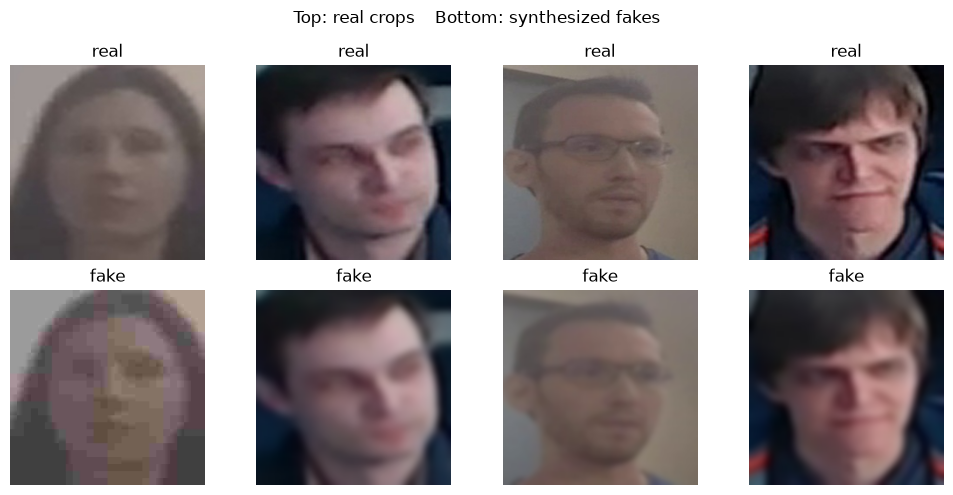

In [6]:
# Peek at what the labels mean: top row real, bottom row the synthesized fake.
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for col in range(4):
    path = train_images[col]
    real_img = Image.open(path).convert("RGB")
    fake_img = corrupt(real_img, seed=col)
    axes[0, col].imshow(real_img); axes[0, col].set_title("real"); axes[0, col].axis("off")
    axes[1, col].imshow(fake_img); axes[1, col].set_title("fake"); axes[1, col].axis("off")
fig.suptitle("Top: real crops    Bottom: synthesized fakes")
plt.tight_layout()
plt.show()

The `DataLoader` batches samples and shuffles the training set each epoch.

In [7]:
BATCH_SIZE = 32
# num_workers=0 keeps this notebook-friendly on Windows (no worker-spawn issues).
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

## 5. A tiny CNN = feature extractor + head

Three conv blocks shrink 224x224 -> 28x28 while growing channels 3 -> 64.
`AdaptiveMaxPool` keeps the strongest activation in each cell of a 2x2 grid per
channel (256 numbers total) — max pooling stays sensitive to the sharp detail our
fakes destroy — and one `Linear` layer — **the head** — maps those to 2 class scores.
On Day 4 we swap this hand-rolled extractor for a pretrained backbone and keep the
same idea of "replace the head."

In [8]:
class TinyCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        # Feature extractor: each block halves H,W and grows the channel count.
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 224 -> 112
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 112 -> 56
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 56 -> 28
        )
        # Pool to a small 2x2 grid. Two choices matter here:
        #  - a 2x2 grid (not 1x1) keeps *where* an artifact sits;
        #  - MAX pooling (not average) keeps the strongest activation, which is
        #    sensitive to sharp detail -- exactly what blur/JPEG destroy. Average
        #    pooling washes that cue out and the model underfits (train loss stalls).
        self.pool = nn.AdaptiveMaxPool2d(2)           # -> (batch, 64, 2, 2)
        self.head = nn.Linear(64 * 2 * 2, n_classes)  # the classification head

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)   # (batch, 256)
        return self.head(x)           # (batch, n_classes) raw logits

model = TinyCNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Trainable parameters: {n_params:,}")

TinyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveMaxPool2d(output_size=2)
  (head): Linear(in_features=256, out_features=2, bias=True)
)
Trainable parameters: 24,098


## 6. Train + validate

`CrossEntropyLoss` on raw logits, Adam optimizer. Each epoch is one training pass
(weights update) followed by one no-grad validation pass reporting loss + accuracy.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 15

def run_epoch(loader, train: bool):
    """One pass over `loader`. Returns (avg_loss, accuracy)."""
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    # No gradient bookkeeping during validation -> faster, less memory.
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total

history = []
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    history.append((train_loss, val_loss, val_acc))
    print(f"epoch {epoch:2d} | train_loss {train_loss:.3f} | "
          f"val_loss {val_loss:.3f} | val_acc {val_acc:.3f}")

epoch  1 | train_loss 0.651 | val_loss 0.598 | val_acc 0.688


epoch  2 | train_loss 0.543 | val_loss 0.529 | val_acc 0.773


epoch  3 | train_loss 0.498 | val_loss 0.463 | val_acc 0.807


epoch  4 | train_loss 0.450 | val_loss 0.451 | val_acc 0.807


epoch  5 | train_loss 0.432 | val_loss 0.422 | val_acc 0.815


...

epoch 11 | train_loss 0.189 | val_loss 0.158 | val_acc 0.932


epoch 12 | train_loss 0.125 | val_loss 0.109 | val_acc 0.977


epoch 13 | train_loss 0.102 | val_loss 0.088 | val_acc 0.977


epoch 14 | train_loss 0.107 | val_loss 0.092 | val_acc 0.980


epoch 15 | train_loss 0.085 | val_loss 0.065 | val_acc 0.983


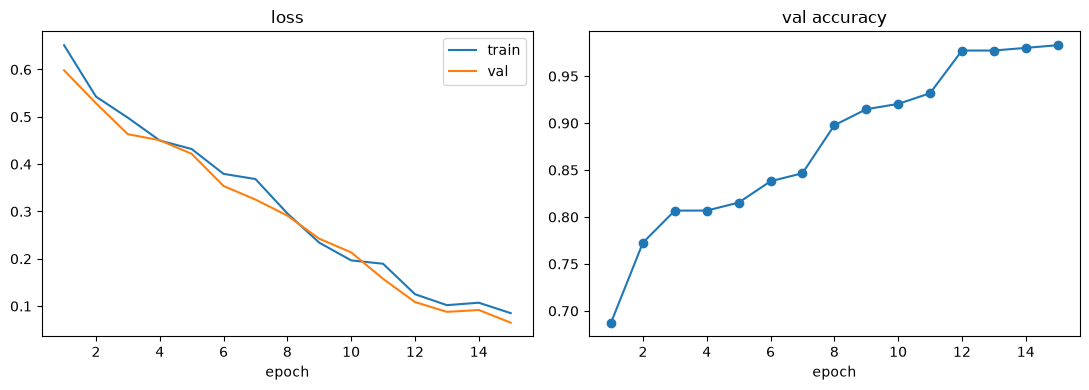

In [10]:
# Sanity check: training loss should fall and val accuracy should climb.
train_losses, val_losses, val_accs = zip(*history)
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(epochs, train_losses, label="train"); ax1.plot(epochs, val_losses, label="val")
ax1.set_title("loss"); ax1.set_xlabel("epoch"); ax1.legend()
ax2.plot(epochs, val_accs, marker="o"); ax2.set_title("val accuracy"); ax2.set_xlabel("epoch")
plt.tight_layout()
plt.show()

## 7. Day 3: richer metrics (AUC-ROC + confusion matrix)

Accuracy alone hides *how* a model is wrong. Two metrics from
[docs/glossary.md](../docs/glossary.md) fix that:

- **AUC-ROC** asks "if I show the model one real and one fake, how often does it
  rank the fake as more suspicious?" It sweeps every possible decision threshold at
  once, so it does not depend on picking 0.5 as the cutoff. 0.5 = coin flip, 1.0 =
  perfect separation.
- **Confusion matrix** breaks accuracy into 4 counts: real correctly called real,
  real wrongly called fake, fake wrongly called real, fake correctly called fake.
  This is where you would spot, e.g., a model that always predicts "real" (high
  accuracy on an imbalanced set, but catches zero fakes).

We run one more no-grad pass over `val_loader`, but this time keep the raw
probabilities instead of just the loss.

In [11]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        probs_fake = torch.softmax(model(images), dim=1)[:, FAKE]  # P(fake)
        all_probs.extend(probs_fake.cpu().tolist())
        all_labels.extend(labels.tolist())

auc = roc_auc_score(all_labels, all_probs)
preds = [1 if p >= 0.5 else 0 for p in all_probs]
cm = confusion_matrix(all_labels, preds)

print(f"AUC-ROC: {auc:.3f}")
print()
print(classification_report(all_labels, preds, target_names=["real", "fake"]))

AUC-ROC: 0.998

              precision    recall  f1-score   support

        real       0.98      0.98      0.98       176
        fake       0.98      0.98      0.98       176

    accuracy                           0.98       352
   macro avg       0.98      0.98      0.98       352
weighted avg       0.98      0.98      0.98       352



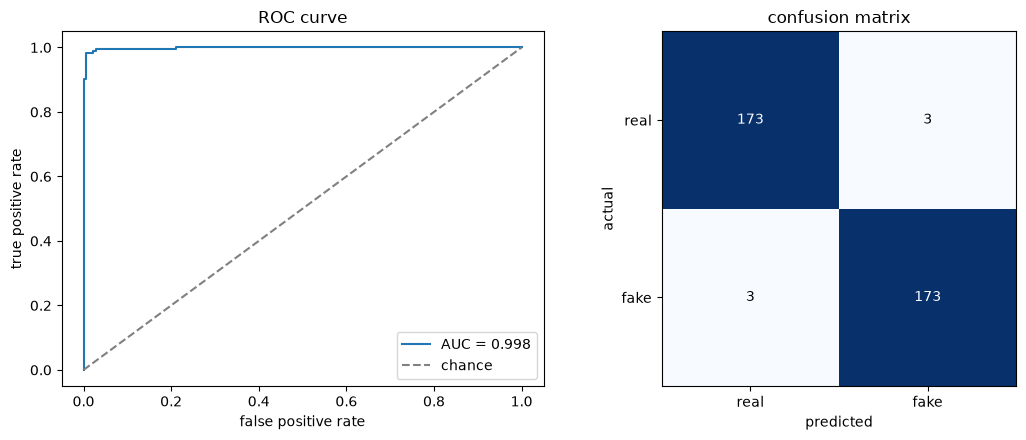

In [12]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# ROC curve: top-left corner = perfect, diagonal = coin flip
ax1.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
ax1.plot([0, 1], [0, 1], "--", color="gray", label="chance")
ax1.set_xlabel("false positive rate"); ax1.set_ylabel("true positive rate")
ax1.set_title("ROC curve"); ax1.legend()

# Confusion matrix as a labeled heatmap
im = ax2.imshow(cm, cmap="Blues")
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["real", "fake"])
ax2.set_yticks([0, 1]); ax2.set_yticklabels(["real", "fake"])
ax2.set_xlabel("predicted"); ax2.set_ylabel("actual"); ax2.set_title("confusion matrix")
for i in range(2):
    for j in range(2):
        ax2.text(j, i, cm[i, j], ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

## 8. Next (Day 4): a real pretrained backbone

Day 4 swaps `TinyCNN.features` for a pretrained backbone from `timm` (starting
with ResNet before Xception), practicing loading weights, freezing/unfreezing,
and a short fine-tuning run — reusing this exact train/validate loop.